In [8]:
# Install required libraries (if not already installed)
!pip install numpy pandas matplotlib scikit-learn

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [9]:
# Simulated vehicle count data (per hour)
hours = np.arange(0, 24)
vehicle_count = np.array([5, 3, 2, 2, 4, 10, 25, 50, 80, 120, 150, 180,
                          200, 210, 220, 200, 180, 150, 120, 90, 60, 40, 20, 10])

# Create DataFrame
df = pd.DataFrame({
    'Hour': hours,
    'Vehicle_Count': vehicle_count
})

df.head()

,Hour,Vehicle_Count
0,0,5
1,1,3
2,2,2
3,3,2
4,4,4


In [10]:
# Polynomial transformation (degree = 3)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(df[['Hour']])

# Train model
model = LinearRegression()
model.fit(X_poly, df['Vehicle_Count'])

# Predict values
df['Predicted_Light_Usage'] = model.predict(X_poly)

In [11]:
# Polynomial transformation (degree = 3)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(df[['Hour']])

# Train model
model = LinearRegression()
model.fit(X_poly, df['Vehicle_Count'])

# Predict values
df['Predicted_Light_Usage'] = model.predict(X_poly)

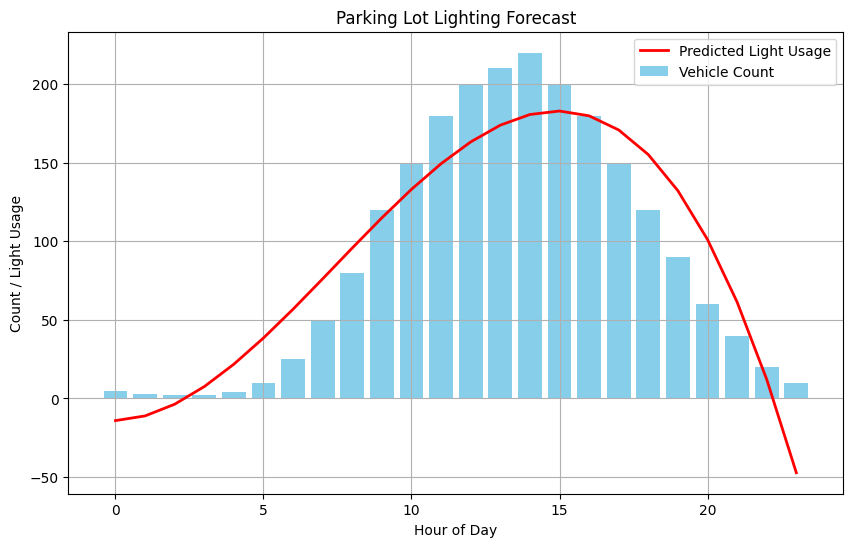

In [12]:
plt.figure(figsize=(10,6))

# Actual vehicle count (bar chart)
plt.bar(df['Hour'], df['Vehicle_Count'], color='skyblue', label='Vehicle Count')

# Predicted light usage (curve)
plt.plot(df['Hour'], df['Predicted_Light_Usage'], color='red', linewidth=2, label='Predicted Light Usage')

plt.xlabel("Hour of Day")
plt.ylabel("Count / Light Usage")
plt.title("Parking Lot Lighting Forecast")
plt.legend()
plt.grid()

plt.show()

In [13]:
# Define anomaly threshold (example: difference > 50)
threshold = 50

df['Anomaly'] = abs(df['Vehicle_Count'] - df['Predicted_Light_Usage']) > threshold

# Print anomalies
print("⚠️ Anomalies Detected:")
print(df[df['Anomaly'] == True])

⚠️ Anomalies Detected:
    Hour  Vehicle_Count  Predicted_Light_Usage  Anomaly
23    23             10             -47.271225     True


In [14]:
import time

print("🔄 Real-time Monitoring Simulation:\n")

for i in range(len(df)):
    actual = df.loc[i, 'Vehicle_Count']
    predicted = df.loc[i, 'Predicted_Light_Usage']

    print(f"Hour {df.loc[i, 'Hour']}: Vehicles={actual}, Predicted Light={round(predicted,2)}")

    if abs(actual - predicted) > threshold:
        print("⚠️ ALERT: Anomaly Detected!\n")

    time.sleep(0.5)  # simulate delay

🔄 Real-time Monitoring Simulation:

Hour 0: Vehicles=5, Predicted Light=-14.11
Hour 1: Vehicles=3, Predicted Light=-11.12
Hour 2: Vehicles=2, Predicted Light=-3.68
Hour 3: Vehicles=2, Predicted Light=7.53
Hour 4: Vehicles=4, Predicted Light=21.81
Hour 5: Vehicles=10, Predicted Light=38.47
Hour 6: Vehicles=25, Predicted Light=56.81
Hour 7: Vehicles=50, Predicted Light=76.13
Hour 8: Vehicles=80, Predicted Light=95.75
Hour 9: Vehicles=120, Predicted Light=114.96
Hour 10: Vehicles=150, Predicted Light=133.08
Hour 11: Vehicles=180, Predicted Light=149.4
Hour 12: Vehicles=200, Predicted Light=163.24
Hour 13: Vehicles=210, Predicted Light=173.9
Hour 14: Vehicles=220, Predicted Light=180.69
Hour 15: Vehicles=200, Predicted Light=182.9
Hour 16: Vehicles=180, Predicted Light=179.85
Hour 17: Vehicles=150, Predicted Light=170.84
Hour 18: Vehicles=120, Predicted Light=155.17
Hour 19: Vehicles=90, Predicted Light=132.16
Hour 20: Vehicles=60, Predicted Light=101.1
Hour 21: Vehicles=40, Predicted Ligh